In [1]:
from dotenv import load_dotenv
import os

In [2]:
import basedosdados as bd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load .env variables
load_dotenv(encoding="utf-16")

project_id = os.getenv("INPE_HOTSPOTS_PROJECT_ID")

query = """
SELECT 
    SAFE.PARSE_DATE('%Y-%m-%d', LEFT(CAST(data_hora AS STRING), 10)) AS data,
    ano,
    mes,
    COUNT(*) AS contagem_focos
FROM `basedosdados.br_inpe_queimadas.microdados` 
WHERE id_municipio = '1302603' 
  AND ano BETWEEN 2016 AND 2024
GROUP BY 1, 2, 3
ORDER BY data ASC
"""

In [4]:
# Execution
try:
    fire_counts_df = bd.read_sql(query=query, billing_project_id=project_id)
    
    # Ensure that the 'data' column is of type datetime for the merge
    fire_counts_df['data'] = pd.to_datetime(fire_counts_df['data'])
    
    print("Daily fire hotspot data for Manaus successfully loaded!")
    print(fire_counts_df)
    
except Exception as e:
    print(f"Error while running the query: {e}")

Downloading: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████|
Daily fire hotspot data for Manaus successfully loaded!
          data   ano  mes  contagem_focos
0   2016-01-09  2016    1               2
1   2016-01-10  2016    1               1
2   2016-01-16  2016    1               5
3   2016-01-18  2016    1               3
4   2016-01-25  2016    1               1
..         ...   ...  ...             ...
496 2024-12-04  2024   12               5
497 2024-12-05  2024   12               4
498 2024-12-08  2024   12               1
499 2024-12-09  2024   12               1
500 2024-12-22  2024   12               2

[501 rows x 4 columns]


In [5]:
fire_counts_df_renamed = fire_counts_df.rename(columns={"data": "date", "ano": "year", "mes": "month", "contagem_focos": "fire_counts"})

fire_counts_df_renamed

,date,year,month,fire_counts
0,2016-01-09,2016,1,2
1,2016-01-10,2016,1,1
2,2016-01-16,2016,1,5
3,2016-01-18,2016,1,3
4,2016-01-25,2016,1,1
...,...,...,...,...
496,2024-12-04,2024,12,5
497,2024-12-05,2024,12,4
498,2024-12-08,2024,12,1
499,2024-12-09,2024,12,1


In [6]:
# --- PART 1: DataFrame Verification and Adjustment ---

# Let's check which columns Python actually received
print("Columns found in the DataFrame:", fire_counts_df_renamed.columns.tolist())

# If the column is named 'DATA' (uppercase) or something similar, let's standardize it:
fire_counts_df_renamed.columns = [c.lower() for c in fire_counts_df_renamed.columns]

# Ensure that the date column is of type datetime
if 'date' in fire_counts_df_renamed.columns:
    fire_counts_df_renamed['date'] = pd.to_datetime(fire_counts_df_renamed['date'])
else:
    # If for some reason the column does not exist, let's try resetting the index
    # (sometimes read_sql already sets the date as the index)
    fire_counts_df_renamed = fire_counts_df_renamed.reset_index()
    fire_counts_df_renamed.columns = [c.lower() for c in fire_counts_df_renamed.columns]
    fire_counts_df_renamed['date'] = pd.to_datetime(fire_counts_df_renamed['date'])

Columns found in the DataFrame: ['date', 'year', 'month', 'fire_counts']


In [7]:
# --- PART 2: Filling Missing Dates ---

start_date = '2016-01-01'
end_date = '2024-12-31'
all_dates = pd.date_range(start=start_date, end=end_date)

# Create the base DataFrame
fire_counts_df_final = pd.DataFrame({'date': all_dates})

# Merge (combine the collected data with the complete calendar)
fire_counts_df_final = fire_counts_df_final.merge(fire_counts_df_renamed, on='date', how='left')

# Fill remaining missing values with 0
fire_counts_df_final['fire_counts'] = fire_counts_df_final['fire_counts'].fillna(0).astype(int)

# Update time columns
fire_counts_df_final['year'] = fire_counts_df_final['date'].dt.year
fire_counts_df_final['month'] = fire_counts_df_final['date'].dt.month

print("Complete daily table successfully generated!")

Complete daily table successfully generated!


In [8]:
fire_counts_df_final

,date,year,month,fire_counts
0,2016-01-01,2016,1,0
1,2016-01-02,2016,1,0
2,2016-01-03,2016,1,0
3,2016-01-04,2016,1,0
4,2016-01-05,2016,1,0
...,...,...,...,...
3283,2024-12-27,2024,12,0
3284,2024-12-28,2024,12,0
3285,2024-12-29,2024,12,0
3286,2024-12-30,2024,12,0


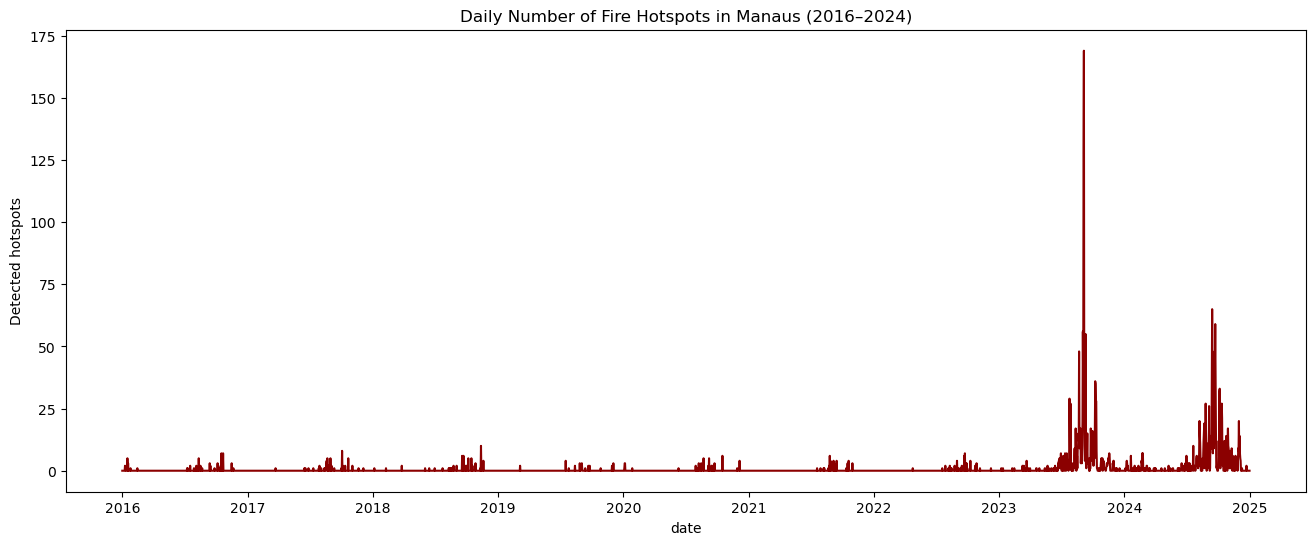

In [9]:
# --- PART 3: Plot ---

plt.figure(figsize=(16, 6))
sns.lineplot(data=fire_counts_df_final, x='date', y='fire_counts', color='darkred')
plt.title('Daily Number of Fire Hotspots in Manaus (2016–2024)')
plt.ylabel('Detected hotspots')
plt.show()